# The curves
We are computing using some heuristics, estimates

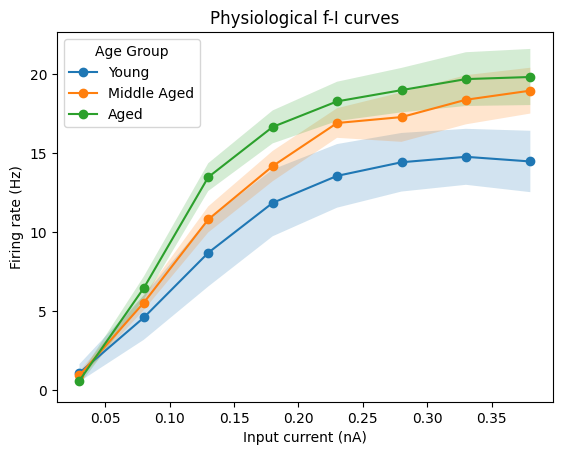

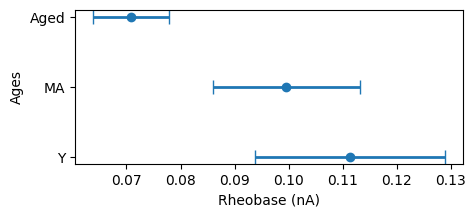

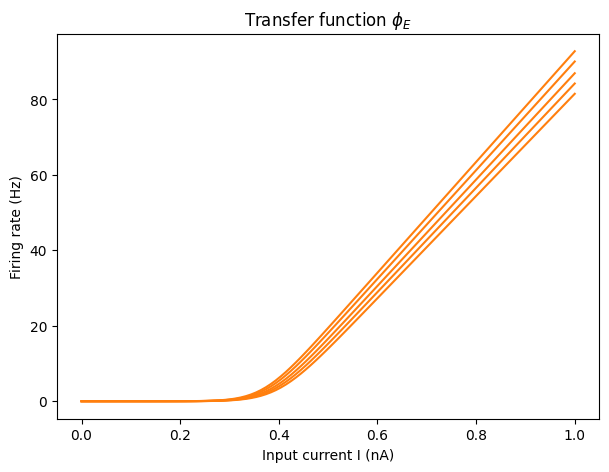

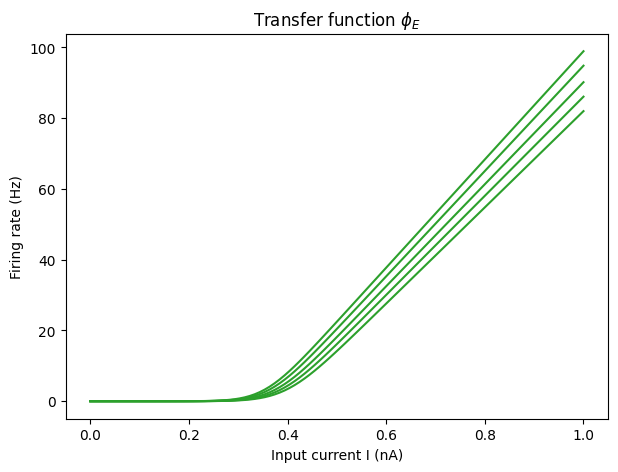

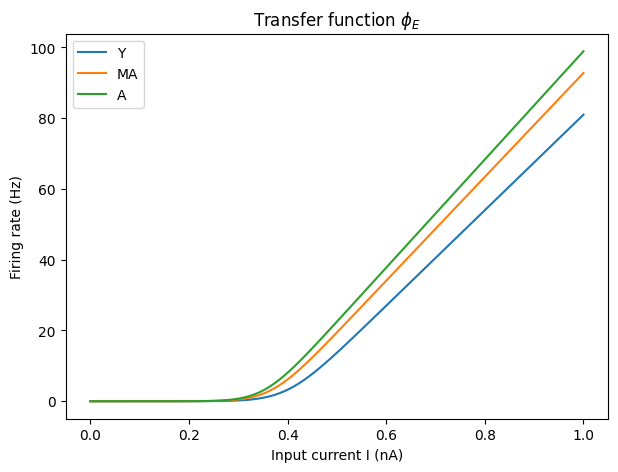

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

full_df = pd.read_excel("data/EPHYS_Aver_byMonkey.xlsx")
df = full_df.iloc[:,14:22].copy()
rb = full_df.iloc[:,[3,24]].copy()

# Define explicit ordering (edit if your labels differ)
age_order = ["Y", "MA", "Aged"]
proper_age_labels = {"Y": 'Young', "MA": 'Middle Aged', "Aged": 'Aged'}

df["Age Group"] = pd.Categorical(full_df["Age Group"], categories=age_order, ordered=True)
rb["Age Group"] = pd.Categorical(rb["Age Group"], categories=age_order, ordered=True)
rb['rheobase'] /= 1000
# Extract input currents from column names (FR_x -> x)
currents = np.array([float(col.split('_')[1])/1000 for col in df.columns[:-1]])

# Group by age and compute stats
group_mean = df.groupby("Age Group",observed=False).mean()
group_sem = df.groupby("Age Group",observed=False).sem()
rheo_mean = rb.groupby("Age Group",observed=False).mean()
rheo_sem = rb.groupby("Age Group",observed=False).sem()

# # Plot FR
# plt.figure(figsize=(7,5))

for g in age_order:
    mean = group_mean.loc[g].values
    sem = group_sem.loc[g].values

    plt.plot(currents, mean, marker='o', label=proper_age_labels[g])
    plt.fill_between(
        currents,
        mean - sem,
        mean + sem,
        alpha=0.2
    )

plt.xlabel("Input current (nA)")
plt.ylabel("Firing rate (Hz)")
plt.legend(title="Age Group")
plt.title(fr'Physiological f-I curves')
plt.savefig(f'Fig/FI curve.svg', dpi=150, bbox_inches='tight')
plt.show()

plt.figure(figsize=(5,2))

# Rheobase
plt.errorbar(rheo_mean.values.squeeze() , age_order, xerr=rheo_sem.values.squeeze(),
    fmt='o', capsize=5, linewidth=2)
plt.ylabel("Ages")
plt.xlabel("Rheobase (nA)")
plt.savefig(f'Fig/rheobase.svg', dpi=150, bbox_inches='tight')
plt.show()

# Plots of Aged FI curve
def phi_E(I, a_E, b_E, d_E):
    x = a_E * I - b_E                 # broadcasts b_E over (30, 100)
    return x / (1 - np.exp(-d_E * x))

xc = np.linspace(0,1,100)

s = 4

plt.figure(figsize=(7,5))

for j in range(s+1):
    i = round(j*(30-1)/s)
    plt.plot(xc,phi_E(xc, np.linspace(135.5, 146.782, 30)[i], 54, 0.308), color='tab:orange')
plt.title(fr'Transfer function $\phi_E$')
plt.xlabel('Input current I (nA)')
plt.ylabel('Firing rate (Hz)')
plt.savefig(f'Fig/MAFI.svg', dpi=150, bbox_inches='tight')
plt.show()

plt.figure(figsize=(7,5))

for j in range(s+1):
    i = round(j*(30-1)/s)
    plt.plot(xc,phi_E(xc, np.linspace(136, 152.931, 30)[i], 54, 0.308), color='tab:green')
plt.title(fr'Transfer function $\phi_E$')
plt.xlabel('Input current I (nA)')
plt.ylabel('Firing rate (Hz)')
plt.savefig(f'Fig/AFI.svg', dpi=150, bbox_inches='tight')
plt.show()

plt.figure(figsize=(7,5))

plt.plot(xc,phi_E(xc, 135, 54, 0.308 ),label='Y')
plt.plot(xc,phi_E(xc, 146.782, 54, 0.308 ),label='MA')
plt.plot(xc,phi_E(xc, 152.931, 54, 0.308 ),label='A')

plt.legend()
plt.title(fr'Transfer function $\phi_E$')
plt.xlabel('Input current I (nA)')
plt.ylabel('Firing rate (Hz)')
plt.savefig(f'Fig/FIchanges.svg', dpi=150, bbox_inches='tight')
plt.show()


Middle Aged: a_E = 146.782, b_E = 54.000
Aged: a_E = 152.931, b_E = 54.000


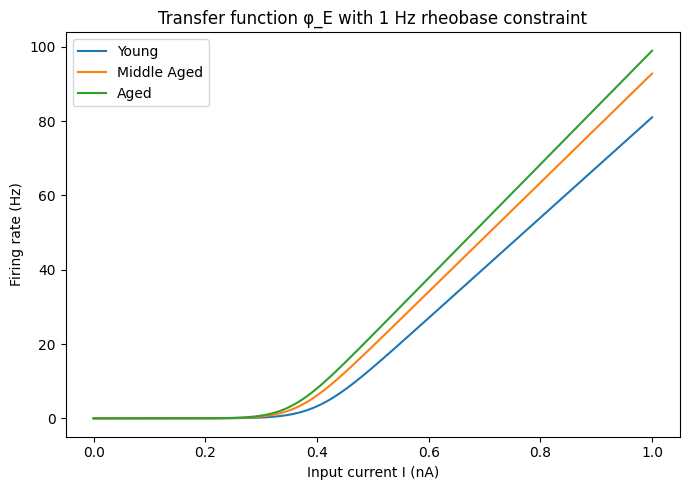

Middle Aged: a_E = 146.782, b_E = 55.000
Aged: a_E = 152.931, b_E = 55.000


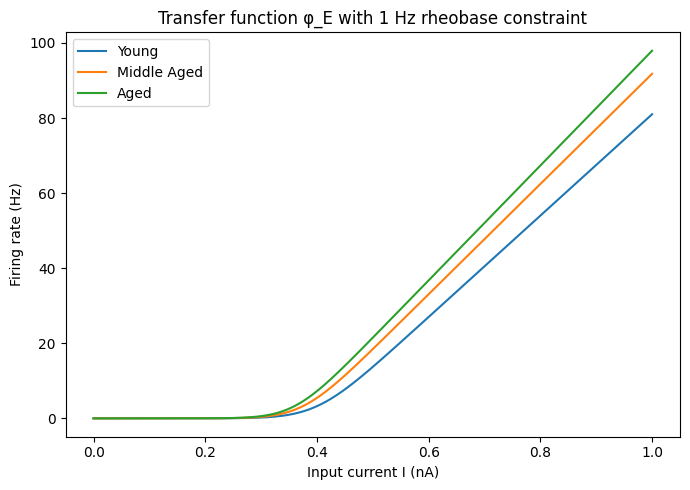

Middle Aged: a_E = 146.782, b_E = 56.000
Aged: a_E = 152.931, b_E = 56.000


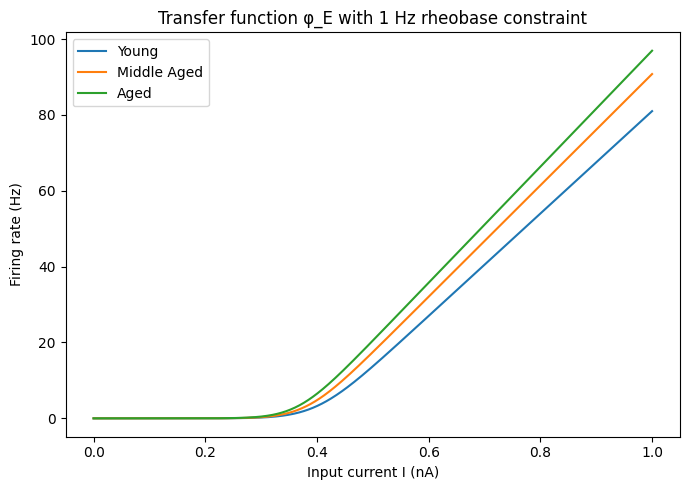

Middle Aged: a_E = 146.782, b_E = 57.000
Aged: a_E = 152.931, b_E = 57.000


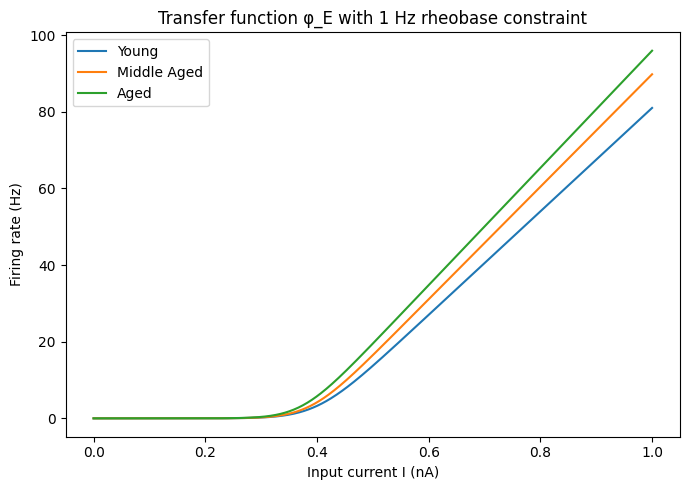

Middle Aged: a_E = 146.782, b_E = 58.000
Aged: a_E = 152.931, b_E = 58.000


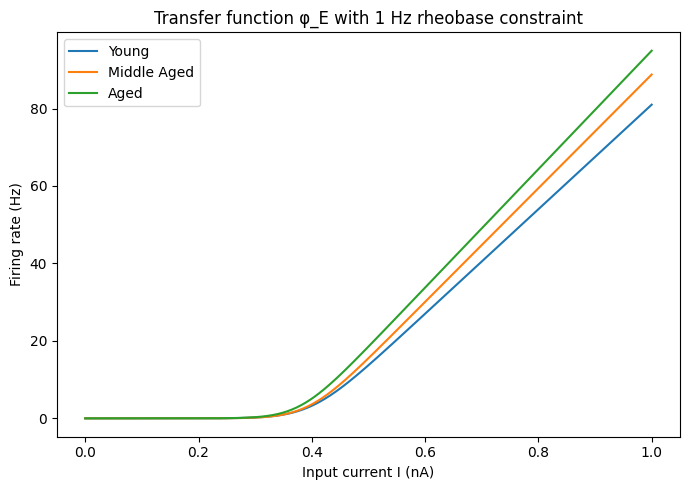

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit, brentq

def aging_a_e(perc, rb_add=0, Plot=False):
    # ── Data ─────────────────────────────────────────────────────────────
    full_df = pd.read_excel("data/EPHYS_Aver_byMonkey.xlsx")
    df = full_df.iloc[:, 14:22].copy()  # Only look at the FI and rheobase data
    rb = full_df[['Age Group', 'rheobase']].copy()

    age_order = ["Y", "MA", "Aged"]
    proper_age_labels = {"Y": "Young", "MA": "Middle Aged", "Aged": "Aged"}

    # Split into ages, averaging
    df["Age Group"] = pd.Categorical(full_df["Age Group"], categories=age_order, ordered=True)
    rb["Age Group"] = pd.Categorical(rb["Age Group"], categories=age_order, ordered=True)
    rb["rheobase"] = rb["rheobase"] / 1000

    group_mean = df.groupby("Age Group",observed=False).mean()
    group_sem = df.groupby("Age Group",observed=False).sem()
    rheo_mean = rb.groupby("Age Group",observed=False).mean()
    rheo_sem = rb.groupby("Age Group",observed=False).sem()

    # Take the Y monkey as baseline
    young_fi = group_mean.loc["Y"].values
    young_rheo = rheo_mean.loc["Y"].values.squeeze()

    # ── Model ────────────────────────────────────────────────────────────
    a_Y, b_Y, d_E = 135, 54, 0.308

    def phi_E(I, a_E, b_E):
        x = a_E * I - b_E
        return x / (1 - np.exp(-d_E * x))

    # 1 Hz rheobase definition
    def rheobase_1hz(a_E, b_E, I_min=0.0, I_max=2.0):
        def f(I):
            return phi_E(I, a_E, b_E) - 1.0
        try:
            return brentq(f, I_min, I_max)
        except ValueError:
            return np.nan

    # Define the Y monkey rheobase
    I_rheo_Y = rheobase_1hz(a_Y, b_Y)

    # Define the Y monkey curve
    xc = np.linspace(0, 1, 500)
    y_young = phi_E(xc, a_Y, b_Y)

    # ── Fit ──────────────────────────────────────────────────────────────
    results = {"Y": {"a": a_Y, "b": b_Y, "label": "Young"}}

    for g in ["MA", "Aged"]:
        # Compute percent change for MA and A with Y as baseline
        pct_fi = np.mean((group_mean.loc[g].values - young_fi) / young_fi * 100)
        pct_rheo = (rheo_mean.loc[g].values.squeeze() - young_rheo) / young_rheo * 100

        # Define the target values of the curves and rheobase with MA and A aging
        y_target = y_young * (1 + pct_fi * perc/ 100)
        target_rheo = I_rheo_Y * (1 + pct_rheo * perc / 100)

        # (starting guess)
        a0 = a_Y * (1 + pct_fi / 100)

        # for each a, solve b such that rheobase matches target
        def solve_b(a_E):
            def err(b):
                r = rheobase_1hz(a_E, b)
                return r - target_rheo
            try:
                return brentq(err, 0.1, 500)
            except ValueError:
                return b_Y
            
        def constrained_model(I, a_E):
            b_E = solve_b(a_E)
            return phi_E(I, a_E, b_E)

        try:
            popt, _ = curve_fit(
                constrained_model,
                xc,
                y_target,
                p0=[a0],
                bounds=([0], [500]),
                maxfev=10000
            )
            a_E = popt[0]
        except RuntimeError:
            a_E = a0

        b_E = solve_b(a_E)

        results[g] = {
            "a": a_E,
            "b": b_E + rb_add,
            "label": proper_age_labels[g],
            "target": y_target
        }

        print(f"{proper_age_labels[g]}: a_E = {a_E:.3f}, b_E = {b_E + rb_add:.3f}")
    if Plot:
        # ── Plot ─────────────────────────────────────────────────────────────
        colors = {"Y": "tab:blue", "MA": "tab:orange", "Aged": "tab:green"}

        fig, ax = plt.subplots(figsize=(7, 5))

        ax.plot(xc, y_young, color=colors["Y"], label="Young")

        for g in ["MA", "Aged"]:
            ax.plot(
                xc,
                phi_E(xc, results[g]["a"], results[g]["b"]),
                color=colors[g],
                label=results[g]["label"]
            )

        ax.set_title("Transfer function φ_E with 1 Hz rheobase constraint")
        ax.set_xlabel("Input current I (nA)")
        ax.set_ylabel("Firing rate (Hz)")
        ax.legend()

        plt.tight_layout()
        # plt.savefig("phi_E_rheobase_constrained.svg", dpi=150, bbox_inches="tight")
        plt.show()


# aging_a_e(0)
# aging_a_e(0.25)
for rb in range(5):
    aging_a_e(1, Plot=True, rb_add=rb)
